In [14]:
import numpy as np
from joblib import Parallel, delayed
from Tracer import Trajectory, WindField, PGA
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pandas as pd

In [ ]:
def get_rotated_geometry(direction, r=150):

    theta = np.deg2rad(direction)

    x = -np.cos(theta) * r
    y = -np.sin(theta) * r

    P0_new = np.array([x, y, 0])

    return P0_new

In [16]:
import os
os.chdir("/work3/s234229")
filenames = {file[9:-16]: file for file in os.listdir("nc files") if file.endswith(".nc")}
display(filenames)

{'z0025m_1m': 'flowdata_z0025m_1m_mb_cartesian.nc',
 'xy8m': 'flowdata_xy8m_mb_cartesian.nc',
 'xy16m': 'flowdata_xy16m_mb_cartesian.nc',
 'z04m_16m': 'flowdata_z04m_16m_mb_cartesian.nc',
 'xy1m': 'flowdata_xy1m_mb_cartesian.nc',
 'z01m_4m': 'flowdata_z01m_4m_mb_cartesian.nc',
 'xy2m': 'flowdata_xy2m_mb_cartesian.nc',
 'z02m_8m': 'flowdata_z02m_8m_mb_cartesian.nc',
 '': 'flowdata_02m_8m.nc',
 'xy4m': 'flowdata_xy4m_mb_cartesian.nc',
 'z005m_2m': 'flowdata_z005m_2m_mb_cartesian.nc'}

In [17]:
wind = {name: WindField(profile='rans', ds=f"nc files/{file}", U_ref=6) for name,file in filenames.items()}
sorted_keys = ['xy1m', 'xy2m', 'xy4m', 'xy8m', 'xy16m', 'z0025m_1m', 'z005m_2m', 'z01m_4m', 'z02m_8m', 'z04m_16m']
plot_keys = ['xy2m', 'xy4m', 'xy8m', 'xy16m', 'z005m_2m', 'z01m_4m', 'z02m_8m', 'z04m_16m']

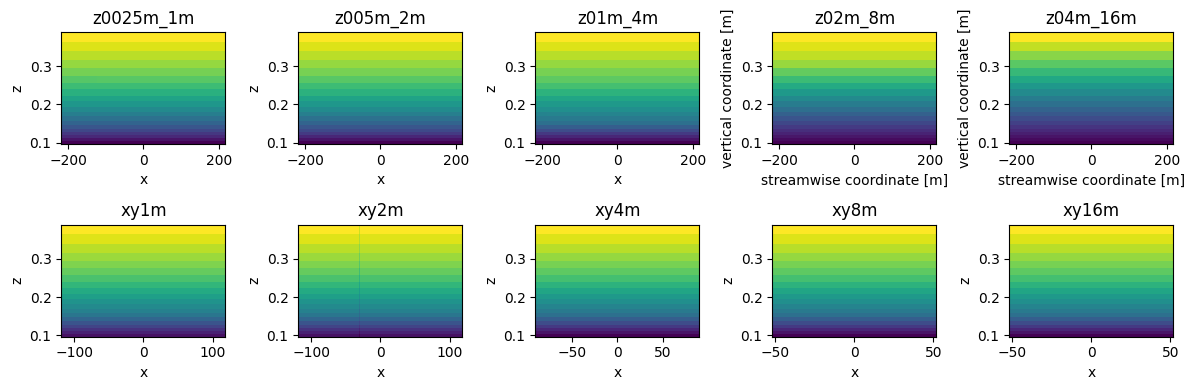

In [18]:
fig, ax = plt.subplots(2, 5, figsize=(12, 4))

i, j = 0, 0
for key in sorted_keys:
    if key.startswith('z'):
        cb = wind[key].ds.isel(y=9, x=slice(10,-10),z=slice(0,20)).U.plot(x='x', y='z', ax=ax[0, i])
        cb.colorbar.remove()
        ax[0, i].set_title(key)
        i += 1
    else:
        cb = wind[key].ds.isel(y=10, x=slice(10,-10),z=slice(0,20)).U.plot(x='x', y='z', ax=ax[1, j])
        cb.colorbar.remove()
        ax[1, j].set_title(key)
        j += 1
plt.tight_layout()

In [19]:
shots = ["Driver", "3-wood", "5-wood", "Hybrid", "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron", "PW"]
# Define a helper function for a single run to be used in parallel processing
def simulate_single_shot(shot_type, wind, solver='rk45', rotation=0):
    # Re-initialize or pass objects safely inside the worker
    P0 = get_rotated_geometry(rotation, r=100)  # Adjust the radius as needed
    traj = PGA(shot_type, wind=wind, orientation=rotation, P0=P0)

    traj.solve(solver)

    return traj.p[-1][:2], np.max(traj.p[:, 2]), P0

In [20]:
# create pandas dataframe to store results for all shots and wind conditions + angles
angles = np.arange(0, 360, 10)

all_tasks = [
    (key, shot, angle)
    for key in filenames
    for shot in shots
    for angle in angles
]

results = Parallel(n_jobs=-1)(
    delayed(simulate_single_shot)(shot, wind[key], rotation=angle)
    for key, shot, angle in all_tasks
)

rows = []
for (key, shot, angle), (landingpoint, max_height, P0) in zip(all_tasks, results):
    rows.append({
        "shot_type": shot,
        "wind_key": key,
        "wind_direction": angle,
        "starting_point": P0,
        "landing_point": landingpoint,
        "x": landingpoint[0],
        "y": landingpoint[1],
        "max_height": max_height,
    })

df = pd.DataFrame(rows)
df

,shot_type,wind_key,wind_direction,starting_point,landing_point,x,y,max_height
0,Driver,z0025m_1m,0,"[-100.0, -0.0, 0.0]","[164.58585562905282, -1.4183715880171733e-05]",164.585856,-0.000014,30.484983
1,Driver,z0025m_1m,10,"[-98.4807753012208, -17.364817766693033, 0.0]","[162.44904905837018, 25.130853454090797]",162.449049,25.130853,30.544387
2,Driver,z0025m_1m,20,"[-93.96926207859084, -34.20201433256687, 0.0]","[155.84454132162256, 49.41886954681235]",155.844541,49.418870,30.720243
3,Driver,z0025m_1m,30,"[-86.60254037844388, -49.99999999999999, 0.0]","[145.0399982567875, 72.02528749289596]",145.039998,72.025287,31.007248
4,Driver,z0025m_1m,40,"[-76.60444431189781, -64.27876096865393, 0.0]","[130.69332479284293, 92.35449763479424]",130.693325,92.354498,31.396351
...,...,...,...,...,...,...,...,...
4351,PW,z005m_2m,310,"[-64.27876096865393, 76.60444431189781, 0.0]","[40.72577688158025, -29.75754025231541]",40.725777,-29.757540,32.653856
4352,PW,z005m_2m,320,"[-76.60444431189778, 64.27876096865396, 0.0]","[45.108359540778935, -25.099175896033664]",45.108360,-25.099176,31.967917
4353,PW,z005m_2m,330,"[-86.60254037844383, 50.00000000000004, 0.0]","[48.910560347755286, -19.700380345780957]",48.910560,-19.700380,31.413995
4354,PW,z005m_2m,340,"[-93.96926207859084, 34.20201433256686, 0.0]","[51.57608496775589, -13.510443390991455]",51.576085,-13.510443,31.007860


In [ ]:
ref_z = df[df['wind_key'] == 'z0025m_1m']
ref_xy = df[df['wind_key'] == 'xy1m']

# find the differnce between the points for each key and the reference points
for key in sorted_keys:
    mask = df['wind_key'] == key
    ref = ref_z if key.startswith('z') else ref_xy
    df.loc[mask, 'x_diff'] = df.loc[mask, 'x'].values - ref['x'].values
    df.loc[mask, 'y_diff'] = df.loc[mask, 'y'].values - ref['y'].values
    df.loc[mask, 'mh_diff'] = df.loc[mask, 'max_height'].values - ref['max_height'].values

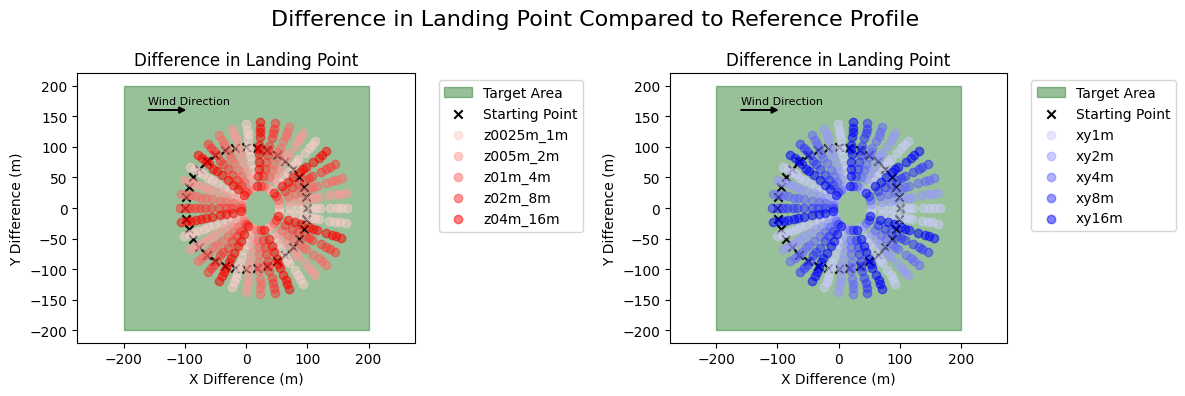

In [102]:
fig, ax = plt.subplots(1,2,figsize=(12, 4))

colors = plt.cm.bwr([0.0, 0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9, 1.0])

ax[0].add_patch(plt.Rectangle((-200, -200), 400, 400, color='darkgreen', alpha=0.4, label='Target Area'))
ax[1].add_patch(plt.Rectangle((-200, -200), 400, 400, color='darkgreen', alpha=0.4, label='Target Area'))
ax[0].scatter(subset['starting_point'][:36].apply(lambda p: p[0]), subset['starting_point'][:36].apply(lambda p: p[1]), alpha=1, marker='x', label='Starting Point', color='black')
ax[1].scatter(subset['starting_point'][:36].apply(lambda p: p[0]), subset['starting_point'][:36].apply(lambda p: p[1]), alpha=1, marker='x', label='Starting Point', color='black')

i, j = 0, 0
for key in sorted_keys:
    subset = df[df['wind_key'] == key]
    if key.startswith('z'):
        subsubset = subset[subset['wind_direction'].isin(np.arange(0, 360, 10*5)+i*10)]
        ax[0].scatter(subsubset['x'], subsubset['y'], label=key, alpha=0.5, color=colors[sorted_keys.index(key)])
        i += 1
    else:
        subsubset = subset[subset['wind_direction'].isin(np.arange(0, 360, 10*5)+j*10)]
        ax[1].scatter(subsubset['x'], subsubset['y'], label=key, alpha=0.5, color=colors[sorted_keys[::-1].index(key)-5])
        j += 1

# add arrow indicating wind direction
ax[0].arrow(-160,160, 50, 0, head_width=10, head_length=10, fc='black', ec='black')
ax[0].text(-160, 170, 'Wind Direction', fontsize=8, ha='left')
ax[1].arrow(-160,160, 50, 0, head_width=10, head_length=10, fc='black', ec='black')
ax[1].text(-160, 170, 'Wind Direction', fontsize=8, ha='left')
ax[0].set_title("Difference in Landing Point")
ax[1].set_title("Difference in Landing Point")
ax[0].set_xlabel("X Difference (m)")
ax[0].set_ylabel("Y Difference (m)")
ax[1].set_xlabel("X Difference (m)")
ax[1].set_ylabel("Y Difference (m)")
ax[0].axis('equal')
ax[1].axis('equal')

ax[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.suptitle("Difference in Landing Point Compared to Reference Profile", fontsize=16)
plt.tight_layout()
plt.show()

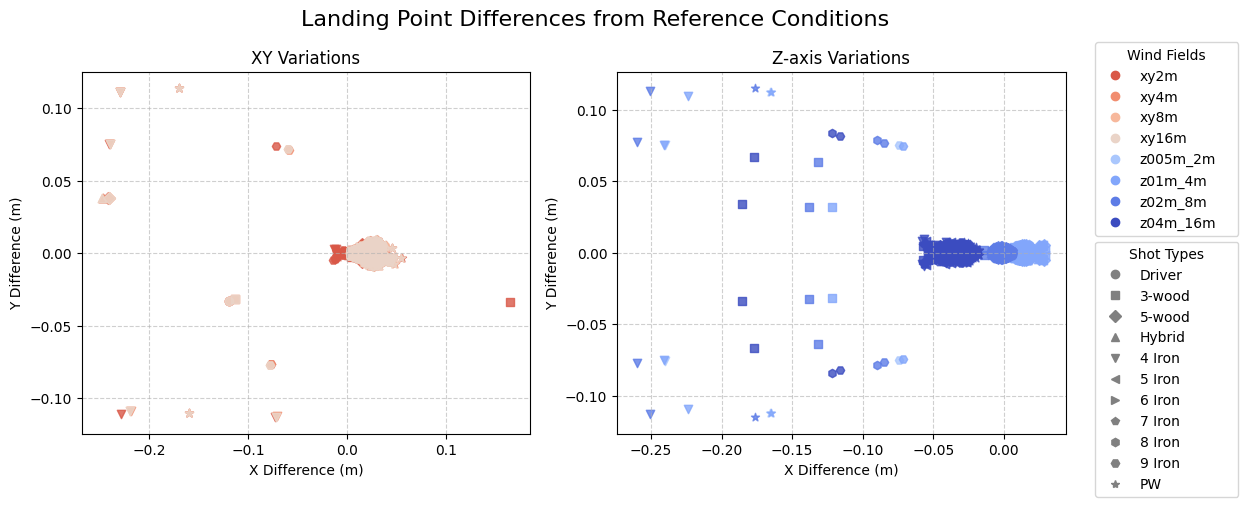

In [103]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5)) # Slightly widened to fit legends side-by-side

# Fixing the color map definition from your snippet
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(sorted_keys)))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', '*']

# 1. Plotting Loop
for key in plot_keys:
    subset = df[df['wind_key'] == key]
    for shot in shots:
        subsubset = subset[subset['shot_type'] == shot]
        
        # Determine correct axis based on key
        target_ax = ax[1] if key.startswith('z') else ax[0]
        
        target_ax.scatter(
            subsubset['x_diff'], 
            subsubset['y_diff'], 
            alpha=0.8, 
            color=colors[sorted_keys.index(key)], 
            marker=markers[shots.index(shot)]
        )

# 2. Define Custom Legend Handles
# Key (Color) Handles
key_handles = [
    mlines.Line2D([], [], color=colors[sorted_keys.index(key)], marker='o', ls='', label=key)
    for key in plot_keys
]

# Shot (Marker) Handles - Using a neutral gray color to focus on the shape
shot_handles = [
    mlines.Line2D([], [], color='gray', marker=markers[shots.index(shot)], ls='', label=shot)
    for shot in shots
]

# 3. Apply Both Legends to the Subplots
# We will put the Keys legend first, then overlay the Shots legend next to it
# Add the Key (Color) Legend
leg1 = ax[1].legend(handles=key_handles, title="Wind Fields", bbox_to_anchor=(1.05, 1.1,0.35,0), loc='upper left', mode="expand")
# Manually add it back so it isn't overwritten
ax[1].add_artist(leg1)

# Add the Shot (Marker) Legend shifted further right (bbox_to_anchor X altered)
ax[1].legend(handles=shot_handles, title="Shot Types", bbox_to_anchor=(1.05, 0.55,0.35,0), loc='upper left', mode="expand")

# 4. Formatting Final Touches
for i in range(2):
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].set_xlabel('X Difference (m)')
    ax[i].set_ylabel('Y Difference (m)')

ax[0].set_title('XY Variations')
ax[1].set_title('Z-axis Variations')

plt.suptitle('Landing Point Differences from Reference Conditions', fontsize=16)

plt.tight_layout()
plt.show()

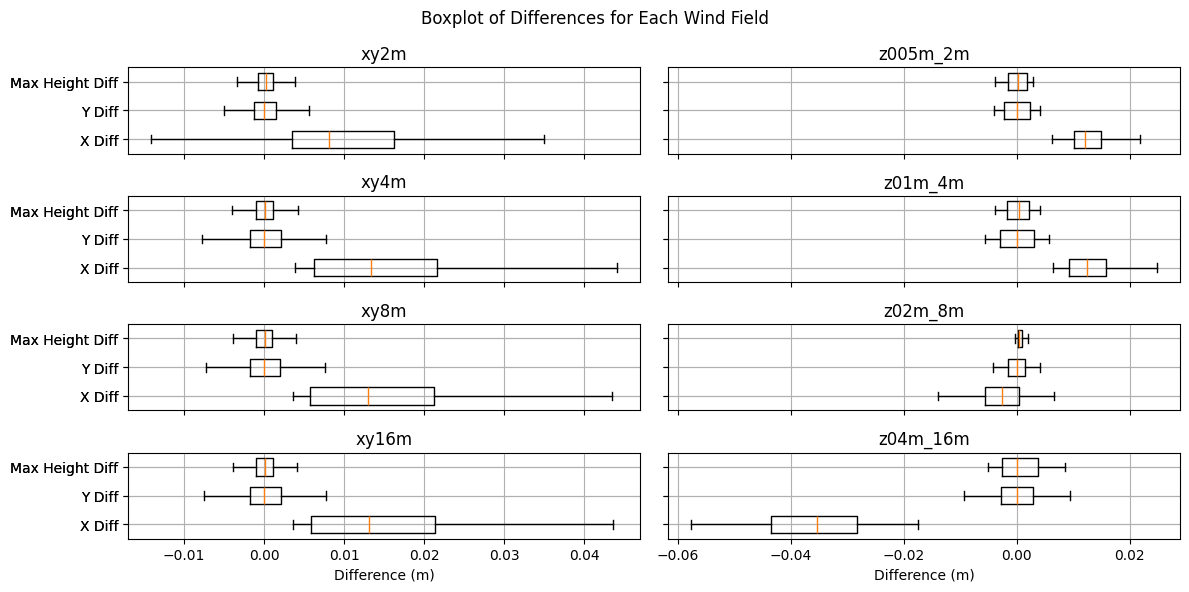

In [104]:
# boxplot of differnces for each key
fig, ax = plt.subplots(4, 2, figsize=(12, 6), sharey='row', sharex='col')
for i, key in enumerate(plot_keys):
    subset = df[df['wind_key'] == key]
    ax[i%4, i//4].boxplot([subset['x_diff'], subset['y_diff'], subset['mh_diff']], tick_labels=['X Diff', 'Y Diff', 'Max Height Diff'], showfliers=False, orientation='horizontal', widths=0.6)
    ax[i%4, i//4].grid()
    ax[i%4, i//4].set_title(key)
ax[3,0].set_xlabel('Difference (m)')
ax[3,1].set_xlabel('Difference (m)')
plt.suptitle('Boxplot of Differences for Each Wind Field')

plt.tight_layout()
plt.show()

In [105]:
# find x and y mean for every wind key in pd.DataFrame
df['abs_diff'] = np.sqrt(df['x_diff']**2 + df['y_diff']**2)

for key in plot_keys:
    key_mask = df['wind_key'] == key
    ref_point = ref_z if key.startswith('z') else ref_xy
    mean_value = np.linalg.norm(df[key_mask][['x', 'y']].values - ref_point[['x', 'y']].values, axis=1).mean()
    df.loc[key_mask, 'mean_distance'] = mean_value


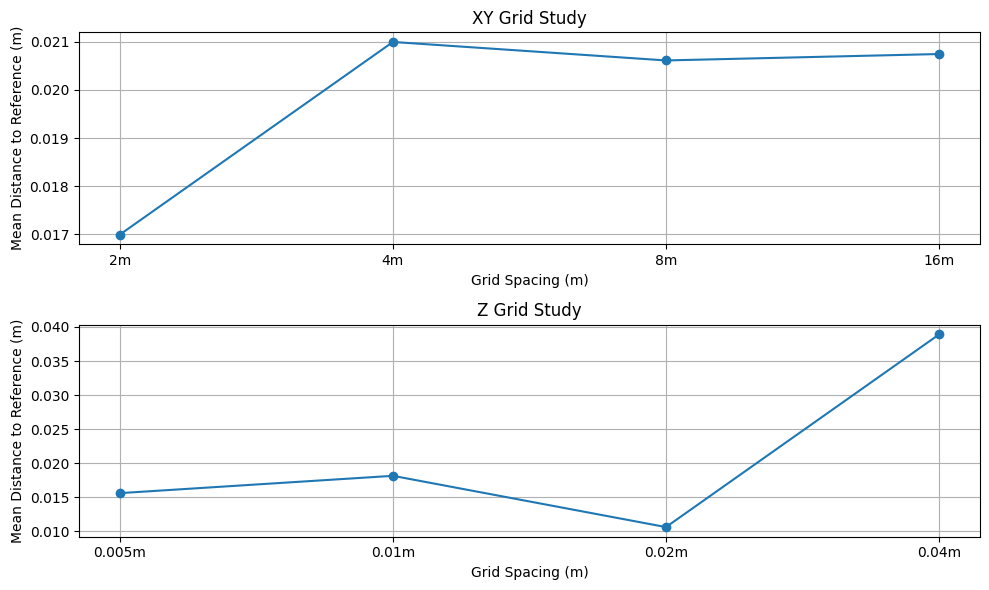

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot([df[df['wind_key'] == key]['mean_distance'].iloc[0] for key in plot_keys if key.startswith('xy')], marker='o')
ax[1].plot([df[df['wind_key'] == key]['mean_distance'].iloc[0] for key in plot_keys if key.startswith('z')], marker='o')

ax[0].grid()
ax[1].grid()
ax[0].set_xticks(range(4))
ax[1].set_xticks(range(4))
ax[0].set_xticklabels(['2m', '4m', '8m', '16m'])
ax[1].set_xticklabels(['0.05m', '0.1m', '0.2m', '0.4m'])
ax[0].set_xlabel('Grid Spacing (m)')
ax[0].set_ylabel('Mean Distance to Reference (m)')
ax[0].set_title('XY Grid Study')
ax[1].set_xlabel('Grid Spacing (m)')
ax[1].set_ylabel('Mean Distance to Reference (m)')
ax[1].set_title('Z Grid Study')
plt.tight_layout()
plt.show()

In [130]:
# create pandas dataframe to store results for all shots and wind conditions + angles
angles = np.arange(0, 360, 10)

wind['log'] = WindField(profile='log', z0=0.0039086, U_ref=6)
filenames['log'] = 'analytical'

all_tasks = [
    (key, shot, angle)
    for key in filenames
    for shot in shots
    for angle in angles
]

results = Parallel(n_jobs=-1)(
    delayed(simulate_single_shot)(shot, wind[key], rotation=angle)
    for key, shot, angle in all_tasks
)

rows = []
for (key, shot, angle), (landingpoint, max_height, P0) in zip(all_tasks, results):
    rows.append({
        "shot_type": shot,
        "wind_key": key,
        "wind_direction": angle,
        "starting_point": P0,
        "landing_point": landingpoint,
        "x": landingpoint[0],
        "y": landingpoint[1],
        "max_height": max_height,
    })

df_wl = pd.DataFrame(rows)
df_wl

,shot_type,wind_key,wind_direction,starting_point,landing_point,x,y,max_height
0,Driver,z0025m_1m,0,"[-100.0, -0.0, 0.0]","[164.58585562905282, -1.4183715880171733e-05]",164.585856,-0.000014,30.484983
1,Driver,z0025m_1m,10,"[-98.4807753012208, -17.364817766693033, 0.0]","[162.44904905837018, 25.130853454090797]",162.449049,25.130853,30.544387
2,Driver,z0025m_1m,20,"[-93.96926207859084, -34.20201433256687, 0.0]","[155.84454132162256, 49.41886954681235]",155.844541,49.418870,30.720243
3,Driver,z0025m_1m,30,"[-86.60254037844388, -49.99999999999999, 0.0]","[145.0399982567875, 72.02528749289596]",145.039998,72.025287,31.007248
4,Driver,z0025m_1m,40,"[-76.60444431189781, -64.27876096865393, 0.0]","[130.69332479284293, 92.35449763479424]",130.693325,92.354498,31.396351
...,...,...,...,...,...,...,...,...
4747,PW,log,310,"[-64.27876096865393, 76.60444431189781, 0.0]","[40.65739443479391, -29.738555014527478]",40.657394,-29.738555,32.664552
4748,PW,log,320,"[-76.60444431189778, 64.27876096865396, 0.0]","[45.20632975118029, -25.19302068983476]",45.206330,-25.193021,31.981574
4749,PW,log,330,"[-86.60254037844383, 50.00000000000004, 0.0]","[48.82575443740606, -19.680745608133527]",48.825754,-19.680746,31.429820
4750,PW,log,340,"[-93.96926207859084, 34.20201433256686, 0.0]","[51.69489067172676, -13.55807160453373]",51.694891,-13.558072,31.025291


In [131]:
ref = df_wl[df_wl['wind_key'] == 'log']

# find the differnce between the points for each key and the reference points
for key in sorted_keys:
    mask = df_wl['wind_key'] == key
    df_wl.loc[mask, 'x_diff'] = df_wl.loc[mask, 'x'].values - ref['x'].values
    df_wl.loc[mask, 'y_diff'] = df_wl.loc[mask, 'y'].values - ref['y'].values
    df_wl.loc[mask, 'mh_diff'] = df_wl.loc[mask, 'max_height'].values - ref['max_height'].values

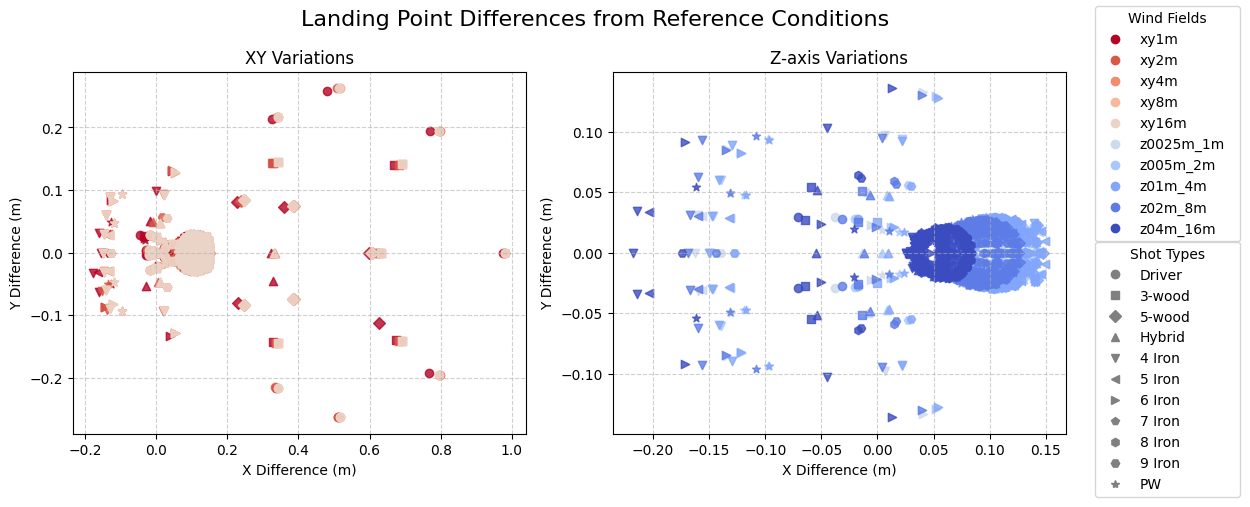

In [132]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5)) # Slightly widened to fit legends side-by-side

# Fixing the color map definition from your snippet
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(sorted_keys)))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', '*']

# 1. Plotting Loop
for key in sorted_keys:
    subset = df_wl[df_wl['wind_key'] == key]
    for shot in shots:
        subsubset = subset[subset['shot_type'] == shot]
        
        # Determine correct axis based on key
        target_ax = ax[1] if key.startswith('z') else ax[0]
        
        target_ax.scatter(
            subsubset['x_diff'], 
            subsubset['y_diff'], 
            alpha=0.8, 
            color=colors[sorted_keys.index(key)], 
            marker=markers[shots.index(shot)]
        )

# 2. Define Custom Legend Handles
# Key (Color) Handles
key_handles = [
    mlines.Line2D([], [], color=colors[sorted_keys.index(key)], marker='o', ls='', label=key)
    for key in sorted_keys
]

# Shot (Marker) Handles - Using a neutral gray color to focus on the shape
shot_handles = [
    mlines.Line2D([], [], color='gray', marker=markers[shots.index(shot)], ls='', label=shot)
    for shot in shots
]

# 3. Apply Both Legends to the Subplots
# We will put the Keys legend first, then overlay the Shots legend next to it
# Add the Key (Color) Legend
leg1 = ax[1].legend(handles=key_handles, title="Wind Fields", bbox_to_anchor=(1.05, 1.2,0.35,0), loc='upper left', mode="expand")
# Manually add it back so it isn't overwritten
ax[1].add_artist(leg1)

# Add the Shot (Marker) Legend shifted further right (bbox_to_anchor X altered)
ax[1].legend(handles=shot_handles, title="Shot Types", bbox_to_anchor=(1.05, 0.55,0.35,0), loc='upper left', mode="expand")

# 4. Formatting Final Touches
for i in range(2):
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].set_xlabel('X Difference (m)')
    ax[i].set_ylabel('Y Difference (m)')

ax[0].set_title('XY Variations')
ax[1].set_title('Z-axis Variations')

plt.suptitle('Landing Point Differences from Reference Conditions', fontsize=16)

plt.tight_layout()
plt.show()

In [133]:
# find x and y mean for every wind key in pd.DataFrame
df_wl['abs_diff'] = np.sqrt(df_wl['x_diff']**2 + df_wl['y_diff']**2)

for key in sorted_keys:
    key_mask = df_wl['wind_key'] == key
    mean_value = np.linalg.norm(df_wl[key_mask][['x', 'y']].values - ref[['x', 'y']].values, axis=1).mean()
    df_wl.loc[key_mask, 'mean_distance'] = mean_value


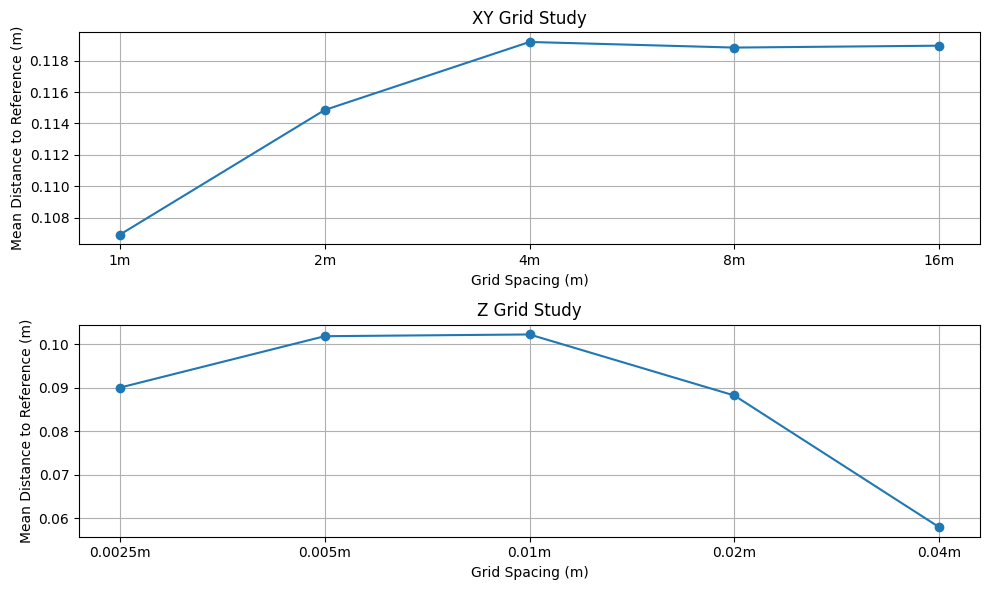

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot([df_wl[df_wl['wind_key'] == key]['mean_distance'].iloc[0] for key in sorted_keys if key.startswith('xy')], marker='o')
ax[1].plot([df_wl[df_wl['wind_key'] == key]['mean_distance'].iloc[0] for key in sorted_keys if key.startswith('z')], marker='o')

ax[0].grid()
ax[1].grid()
ax[0].set_xticks(range(5))
ax[1].set_xticks(range(5))
ax[0].set_xticklabels(['1m', '2m', '4m', '8m', '16m'])
ax[1].set_xticklabels(['0.025m','0.05m', '0.1m', '0.2m', '0.4m'])
ax[0].set_xlabel('Grid Spacing (m)')
ax[0].set_ylabel('Mean Distance to Reference (m)')
ax[0].set_title('XY Grid Study')
ax[1].set_xlabel('Grid Spacing (m)')
ax[1].set_ylabel('Mean Distance to Reference (m)')
ax[1].set_title('Z Grid Study')
plt.tight_layout()
plt.show()